# BioGlyph — face image pipeline

This notebook explores **face parsing** for the BioGlyph project: classical skeletonization, **MediaPipe** face landmarks, optional **pose** hints, **multiclass segmentation** (hair / face skin), and **vector-style part outlines** (face oval, smoothed hair, features, ears).

## Inputs

- **`face.jpg`** — portrait used in **every** cell (place it in the project root).
- **Downloaded models** (cached in the project root on first run): `face_landmarker.task`, `pose_landmarker_full.task`, `selfie_multiclass_256x256.tflite`.

## Cell guide

The cells below are grouped as: *intro markdown* → *code*. Each code cell is self-contained; execute in order the first time so models download.



### Cell 1 — Grayscale skeletonization (`scikit-image`)

**Purpose:** Binarize **`face.jpg`** with Otsu, then **`skeletonize`** to a 1-pixel-wide medial axis. This is a small classical-vision demo and is **independent** of the MediaPipe pipeline below.


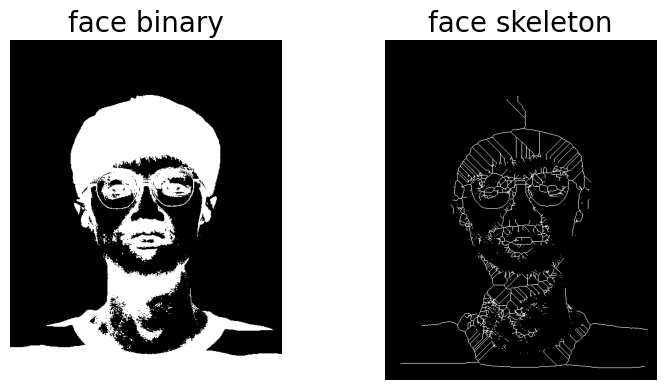

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.morphology import skeletonize
from skimage.util import invert

# Load local face image
face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

face = imread(face_path)
if face.ndim == 3:
    face = rgb2gray(face)

# Convert photo to binary mask before skeletonization
thresh = threshold_otsu(face)
face_binary = face < thresh

# Keep object as foreground (True) when needed
if face_binary.mean() > 0.5:
    face_binary = invert(face_binary)

face_skeleton = skeletonize(face_binary)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(face_binary, cmap=plt.cm.gray)
ax[0].axis("off")
ax[0].set_title("face binary", fontsize=20)

ax[1].imshow(face_skeleton, cmap=plt.cm.gray)
ax[1].axis("off")
ax[1].set_title("face skeleton", fontsize=20)

fig.tight_layout()
plt.show()


### Cell 2 — MediaPipe face mesh (2D + 3D)

**Purpose:** Load **`face.jpg`**, run **Face Landmarker**, draw the **tessellation** on the image and a **3D scatter** of landmarks (x, y, z). Requires `face_landmarker.task`.


I0000 00:00:1778497665.373526 13076156 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
W0000 00:00:1778497665.375345 13076156 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778497665.481470 13076156 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778497665.483393 13076163 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497665.494962 13076161 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


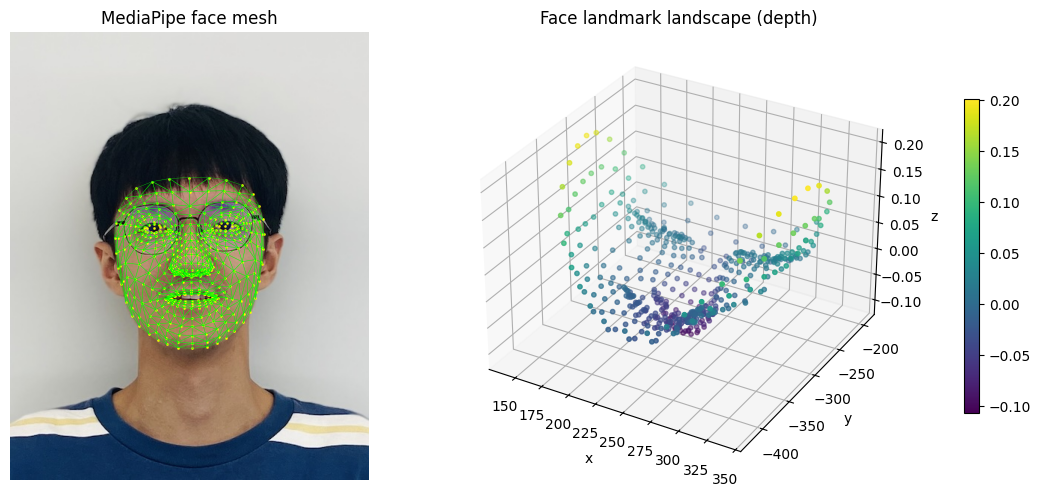

In [2]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from skimage.io import imread

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

# MediaPipe Tasks API needs a .task model file.
model_path = Path("face_landmarker.task")
if not model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
        model_path,
    )

img = imread(face_path)
if img.ndim != 3:
    raise ValueError("face.jpg should be a color image for MediaPipe landmarks")

rgb = img[:, :, :3]
h, w, _ = rgb.shape

base_options = mp_python.BaseOptions(model_asset_path=str(model_path))
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
)
landmarker = vision.FaceLandmarker.create_from_options(options)

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
results = landmarker.detect(mp_image)
landmarker.close()

if not results.face_landmarks:
    raise ValueError("No face detected in face.jpg")

landmarks = results.face_landmarks[0]
xy = np.array([(lm.x * w, lm.y * h) for lm in landmarks])
z = np.array([lm.z for lm in landmarks])

fig = plt.figure(figsize=(12, 5))

# 2D mesh overlay
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(rgb)
for conn in vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION:
    i, j = conn.start, conn.end
    ax1.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color="lime", linewidth=0.3, alpha=0.7)
ax1.scatter(xy[:, 0], xy[:, 1], s=1, c="yellow", alpha=0.8)
ax1.axis("off")
ax1.set_title("MediaPipe face mesh")

# 3D landmark landscape (depth map)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
scatter = ax2.scatter(xy[:, 0], -xy[:, 1], z, c=z, cmap="viridis", s=10)
ax2.set_title("Face landmark landscape (depth)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
fig.colorbar(scatter, ax=ax2, shrink=0.7, pad=0.1)

plt.tight_layout()
plt.show()


### Cell 3 — Face feature polylines (oval, brows, eyes, nose, lips)

**Purpose:** Same landmarker on **`face.jpg`**, but draw **connected outline groups** (face oval, eyebrows, eyes, irises, nose, lips) in distinct colors—flat “line art” without the full mesh.


W0000 00:00:1778497666.156766 13076183 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778497666.162684 13076183 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497666.163563 13076185 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497666.169989 13076185 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/28964764.py:68: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/28964764.py:68: UserWarning: Glyph 23448 (\N{CJK UNIFIED IDEOGRAPH-5B98}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/subairui/Documents/projects/bio-glyph/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/subairui/Documents/projects/bio-glyph/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23448 (\N{CJK UNIFIED IDEOGRAPH-5B98}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


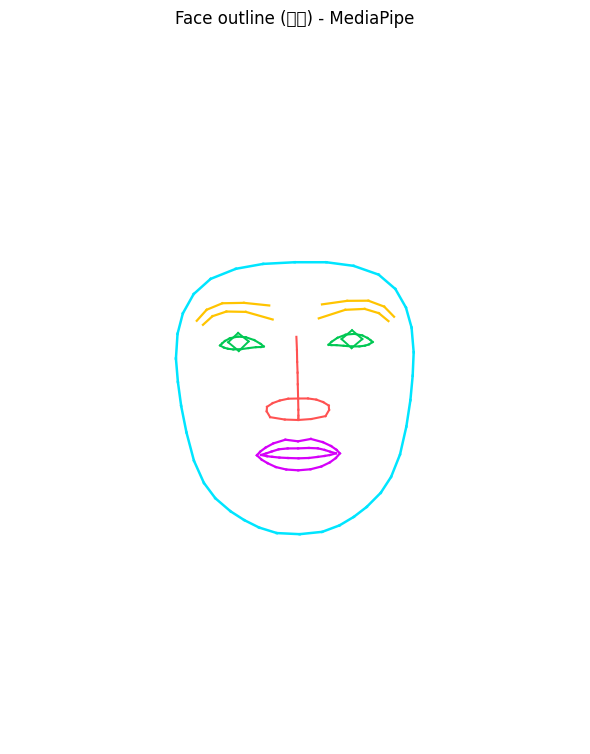

In [3]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from skimage.io import imread

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

model_path = Path("face_landmarker.task")
if not model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
        model_path,
    )

rgb = imread(face_path)[:, :, :3]
h, w, _ = rgb.shape

base_options = mp_python.BaseOptions(model_asset_path=str(model_path))
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
)
landmarker = vision.FaceLandmarker.create_from_options(options)
results = landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
landmarker.close()

if not results.face_landmarks:
    raise ValueError("No face detected in face.jpg")

landmarks = results.face_landmarks[0]
xy = np.array([(lm.x * w, lm.y * h) for lm in landmarks])

# 五官 + face contour outlines
outline_groups = [
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_FACE_OVAL, "#00e5ff", 1.8),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYEBROW, "#ffc400", 1.6),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYEBROW, "#ffc400", 1.6),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYE, "#00c853", 1.5),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYE, "#00c853", 1.5),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS, "#00c853", 1.4),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS, "#00c853", 1.4),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_NOSE, "#ff5252", 1.5),
    (vision.FaceLandmarksConnections.FACE_LANDMARKS_LIPS, "#d500f9", 1.6),
]

fig, ax = plt.subplots(figsize=(6, 8))
ax.set_facecolor("white")

for connections, color, lw in outline_groups:
    for conn in connections:
        i, j = conn.start, conn.end
        ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]], color=color, linewidth=lw)

ax.set_xlim(0, w)
ax.set_ylim(h, 0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Face outline (五官) - MediaPipe")

plt.tight_layout()
plt.show()


### Cell 4 — Pose ear points + segmentation contours

**Purpose:** Use **`face.jpg`**, **Pose Landmarker** (coarse ear indices) and **Image Segmenter** to draw **hair** and **face-skin** mask contours, plus ear point markers. Good for comparing segmentation boundaries to landmarks.


I0000 00:00:1778497666.549742 13076232 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3


W0000 00:00:1778497666.613479 13076235 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497666.637031 13076234 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497666.661920 13076239 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


I0000 00:00:1778497666.766707 13076250 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497666.804898 13076252 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


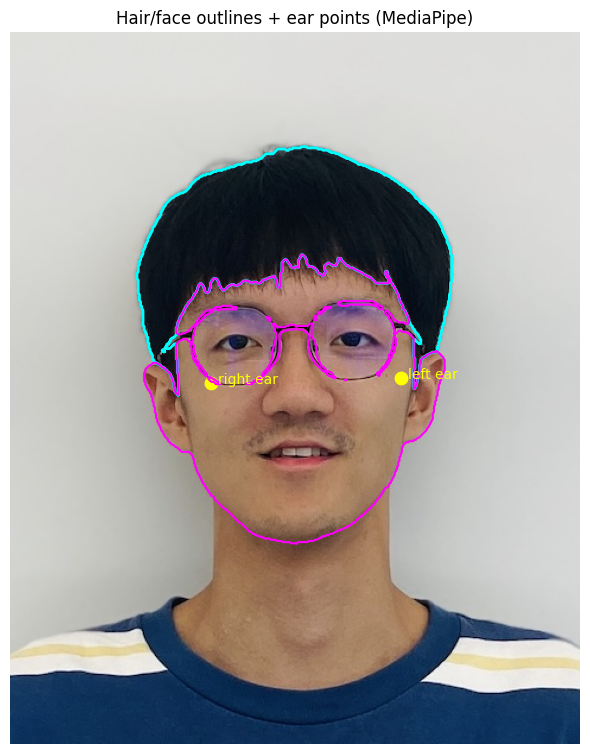

In [4]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from skimage.io import imread
from skimage.measure import find_contours

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

pose_model_path = Path("pose_landmarker_full.task")
if not pose_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task",
        pose_model_path,
    )

segmenter_model_path = Path("selfie_multiclass_256x256.tflite")
if not segmenter_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite",
        segmenter_model_path,
    )

rgb = imread(face_path)[:, :, :3]
h, w, _ = rgb.shape
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

# 1) Pose: get coarse ear points
pose_options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(pose_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1,
)
pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)
pose_result = pose_landmarker.detect(mp_image)
pose_landmarker.close()

left_ear_xy = right_ear_xy = None
if pose_result.pose_landmarks:
    plm = pose_result.pose_landmarks[0]
    left_ear_xy = (plm[7].x * w, plm[7].y * h)
    right_ear_xy = (plm[8].x * w, plm[8].y * h)

# 2) Segmentation: get hair / face-skin masks
seg_options = vision.ImageSegmenterOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(segmenter_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    output_category_mask=True,
)
segmenter = vision.ImageSegmenter.create_from_options(seg_options)
seg_result = segmenter.segment(mp_image)
segmenter.close()

category_mask = np.squeeze(seg_result.category_mask.numpy_view())

# Labels for selfie_multiclass_256x256:
# 0 background, 1 hair, 2 body-skin, 3 face-skin, 4 clothes, 5 others
hair_mask = category_mask == 1
face_skin_mask = category_mask == 3

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(rgb)

# Draw mask contours as outlines
for contour in find_contours(hair_mask.astype(float), level=0.5):
    ax.plot(contour[:, 1], contour[:, 0], color="cyan", linewidth=2.0, label="hair outline")
for contour in find_contours(face_skin_mask.astype(float), level=0.5):
    ax.plot(contour[:, 1], contour[:, 0], color="magenta", linewidth=1.5, label="face-skin outline")

# Draw coarse ear points
if left_ear_xy is not None and right_ear_xy is not None:
    ax.scatter([left_ear_xy[0], right_ear_xy[0]], [left_ear_xy[1], right_ear_xy[1]], c="yellow", s=80)
    ax.text(left_ear_xy[0] + 6, left_ear_xy[1], "left ear", color="yellow", fontsize=10)
    ax.text(right_ear_xy[0] + 6, right_ear_xy[1], "right ear", color="yellow", fontsize=10)

ax.set_title("Hair/face outlines + ear points (MediaPipe)")
ax.axis("off")
plt.tight_layout()
plt.show()


### Cell 5 — Filled part overlay (convex regions + masks)

**Purpose:** **`face.jpg`** — combine **hair** and **face_skin** segmentation with **convex hulls** of landmark groups (eyes, brows, nose, mouth). Shows **color-filled regions** on the photo and on a white background (no ear split).


W0000 00:00:1778497667.214888 13076292 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778497667.221116 13076292 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497667.221851 13076296 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497667.234556 13076300 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1778497667.334925 13076306 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497667.395172 13076309 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497667.403334 13076315 inference_feedback_manager.cc:121] Feedback manager req

I0000 00:00:1778497667.511889 13076316 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497667.522579 13076318 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


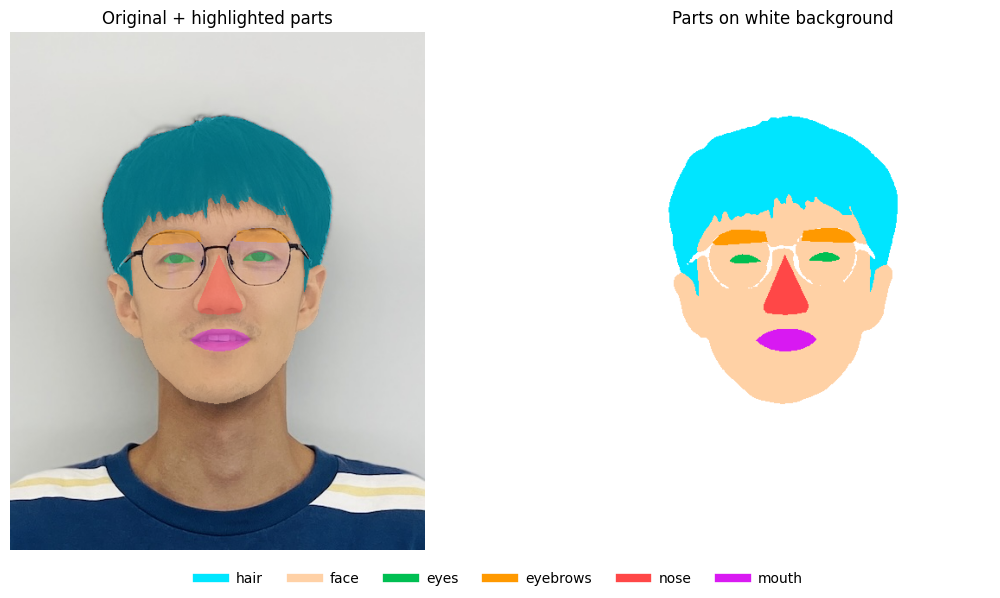

In [5]:
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.spatial import ConvexHull
from skimage.draw import disk, polygon
from skimage.io import imread

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

# Model files (download once)
face_model_path = Path("face_landmarker.task")
if not face_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
        face_model_path,
    )

pose_model_path = Path("pose_landmarker_full.task")
if not pose_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task",
        pose_model_path,
    )

segmenter_model_path = Path("selfie_multiclass_256x256.tflite")
if not segmenter_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite",
        segmenter_model_path,
    )

rgb = imread(face_path)[:, :, :3]
h, w, _ = rgb.shape
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

# -------- MediaPipe inference --------
# Face landmarks
face_options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(face_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
)
face_landmarker = vision.FaceLandmarker.create_from_options(face_options)
face_result = face_landmarker.detect(mp_image)
face_landmarker.close()
if not face_result.face_landmarks:
    raise ValueError("No face landmarks detected in face.jpg")

landmarks = face_result.face_landmarks[0]
xy = np.array([(lm.x * w, lm.y * h) for lm in landmarks])

# Pose (for coarse ear points)
pose_options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(pose_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1,
)
pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)
pose_result = pose_landmarker.detect(mp_image)
pose_landmarker.close()

# Selfie multiclass segmentation (hair)
seg_options = vision.ImageSegmenterOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(segmenter_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    output_category_mask=True,
)
segmenter = vision.ImageSegmenter.create_from_options(seg_options)
seg_result = segmenter.segment(mp_image)
segmenter.close()
category_mask = np.squeeze(seg_result.category_mask.numpy_view())
hair_mask = category_mask == 1
face_skin_mask = category_mask == 3

# -------- Helper functions --------
def idx_from_connections(connections):
    ids = set()
    for c in connections:
        ids.add(c.start)
        ids.add(c.end)
    return sorted(ids)


def convex_region_mask(points_xy, shape_hw):
    m = np.zeros(shape_hw, dtype=bool)
    pts = np.asarray(points_xy)
    if pts.shape[0] < 3:
        return m
    pts = np.unique(pts, axis=0)
    if pts.shape[0] < 3:
        return m
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    rr, cc = polygon(hull_pts[:, 1], hull_pts[:, 0], shape=shape_hw)
    m[rr, cc] = True
    return m


# -------- Build per-part masks --------
left_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYE)
right_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYE)
left_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYEBROW)
right_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYEBROW)
nose_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_NOSE)
mouth_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LIPS)
face_oval_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_FACE_OVAL)

eyes_mask = convex_region_mask(xy[left_eye_idx], (h, w)) | convex_region_mask(xy[right_eye_idx], (h, w))
eyebrows_mask = convex_region_mask(xy[left_brow_idx], (h, w)) | convex_region_mask(xy[right_brow_idx], (h, w))
nose_mask = convex_region_mask(xy[nose_idx], (h, w))
mouth_mask = convex_region_mask(xy[mouth_idx], (h, w))

# -------- Visualization --------
part_colors = {
    "hair": np.array([0.00, 0.90, 1.00]),      # cyan
    "face": np.array([1.00, 0.82, 0.65]),      # skin tone
    "eyes": np.array([0.00, 0.75, 0.32]),      # green
    "eyebrows": np.array([1.00, 0.60, 0.00]),  # orange
    "nose": np.array([1.00, 0.28, 0.28]),      # red
    "mouth": np.array([0.85, 0.10, 0.95]),     # magenta
}

part_masks = {
    "hair": hair_mask,
    "face": face_skin_mask,
    "eyes": eyes_mask,
    "eyebrows": eyebrows_mask,
    "nose": nose_mask,
    "mouth": mouth_mask,
}

orig = rgb.astype(np.float32) / 255.0
overlay = orig.copy()
white_bg = np.ones_like(orig)
alpha = 0.45

for part_name, mask in part_masks.items():
    color = part_colors[part_name]
    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color
    white_bg[mask] = color

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
axes[0].imshow(overlay)
axes[0].set_title("Original + highlighted parts")
axes[0].axis("off")

axes[1].imshow(white_bg)
axes[1].set_title("Parts on white background")
axes[1].axis("off")

legend_lines = [
    plt.Line2D([0], [0], color=part_colors[k], lw=6, label=k)
    for k in ["hair", "face", "eyes", "eyebrows", "nose", "mouth"]
]
fig.legend(handles=legend_lines, loc="lower center", ncol=6, frameon=False)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()


### Cell 6 — Part outlines (production-style line art)

**Purpose:** **`face.jpg`** — one continuous **face oval** polyline (landmarks), **hair** contour from segmentation, and **feature** outlines from convex masks. Baseline “BioGlyph” outline look.


W0000 00:00:1778497667.815158 13076328 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778497667.817433 13076328 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497667.818250 13076332 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497667.824079 13076335 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1778497667.917521 13076338 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497667.927625 13076340 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


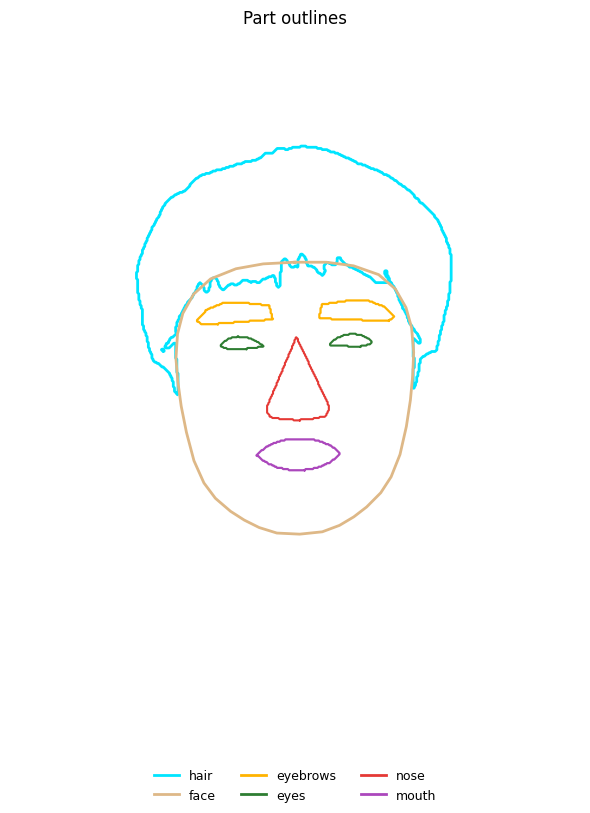

In [6]:
# Part outlines only: face oval from landmarks; hair from segmentation
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from collections import defaultdict
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.spatial import ConvexHull
from skimage.draw import polygon
from skimage.io import imread
from skimage.measure import find_contours

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

face_model_path = Path("face_landmarker.task")
if not face_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
        face_model_path,
    )
segmenter_model_path = Path("selfie_multiclass_256x256.tflite")
if not segmenter_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite",
        segmenter_model_path,
    )

rgb = imread(face_path)[:, :, :3]
h, w, _ = rgb.shape
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)


def idx_from_connections(connections):
    ids = set()
    for c in connections:
        ids.add(c.start)
        ids.add(c.end)
    return sorted(ids)


def convex_region_mask(points_xy, shape_hw):
    m = np.zeros(shape_hw, dtype=bool)
    pts = np.asarray(points_xy)
    if pts.shape[0] < 3:
        return m
    pts = np.unique(pts, axis=0)
    if pts.shape[0] < 3:
        return m
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    rr, cc = polygon(hull_pts[:, 1], hull_pts[:, 0], shape=shape_hw)
    m[rr, cc] = True
    return m


def plot_mask_outlines(ax, mask, color, linewidth=1.8):
    for contour in find_contours(mask.astype(float), level=0.5):
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=linewidth)


def face_oval_cycle_ordered():
    conns = list(vision.FaceLandmarksConnections.FACE_LANDMARKS_FACE_OVAL)
    adj = defaultdict(set)
    for c in conns:
        adj[c.start].add(c.end)
        adj[c.end].add(c.start)
    start = min(adj.keys())
    order = [start]
    prev, cur = None, start
    for _ in range(len(adj)):
        nbrs = [n for n in adj[cur] if n != prev]
        if not nbrs:
            break
        nxt = nbrs[0]
        order.append(nxt)
        prev, cur = cur, nxt
    return order[:-1]


# Face landmarks
face_options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(face_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
)
face_landmarker = vision.FaceLandmarker.create_from_options(face_options)
face_result = face_landmarker.detect(mp_image)
face_landmarker.close()
if not face_result.face_landmarks:
    raise ValueError("No face landmarks detected in face.jpg")

landmarks = face_result.face_landmarks[0]
xy = np.array([(lm.x * w, lm.y * h) for lm in landmarks])

# Segmentation (hair)
seg_options = vision.ImageSegmenterOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(segmenter_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    output_category_mask=True,
)
segmenter = vision.ImageSegmenter.create_from_options(seg_options)
seg_result = segmenter.segment(mp_image)
segmenter.close()
category_mask = np.squeeze(seg_result.category_mask.numpy_view())
hair_mask = category_mask == 1

# Facial feature masks (left/right kept separate)
left_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYE)
right_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYE)
left_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYEBROW)
right_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYEBROW)
nose_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_NOSE)
mouth_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LIPS)

left_eye_mask = convex_region_mask(xy[left_eye_idx], (h, w))
right_eye_mask = convex_region_mask(xy[right_eye_idx], (h, w))
left_brow_mask = convex_region_mask(xy[left_brow_idx], (h, w))
right_brow_mask = convex_region_mask(xy[right_brow_idx], (h, w))
nose_mask = convex_region_mask(xy[nose_idx], (h, w))
mouth_mask = convex_region_mask(xy[mouth_idx], (h, w))

# One continuous closed polyline for the whole face oval (no splitting into arcs)
oval_lm = face_oval_cycle_ordered()
oval_closed = np.array(oval_lm + [oval_lm[0]], dtype=int)
oval_xy = xy[oval_closed]

fig, ax = plt.subplots(figsize=(6, 8))
ax.set_facecolor("white")

plot_mask_outlines(ax, hair_mask, "#00e5ff", linewidth=2.0)
ax.plot(oval_xy[:, 0], oval_xy[:, 1], color="#deb887", linewidth=2.0)

plot_mask_outlines(ax, left_brow_mask, "#ffb300", 1.6)
plot_mask_outlines(ax, right_brow_mask, "#ffb300", 1.6)
plot_mask_outlines(ax, left_eye_mask, "#2e7d32", 1.5)
plot_mask_outlines(ax, right_eye_mask, "#2e7d32", 1.5)
plot_mask_outlines(ax, nose_mask, "#e53935", 1.5)
plot_mask_outlines(ax, mouth_mask, "#ab47bc", 1.6)

ax.set_xlim(0, w)
ax.set_ylim(h, 0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Part outlines")

legend_elems = [
    plt.Line2D([0], [0], color="#00e5ff", lw=2, label="hair"),
    plt.Line2D([0], [0], color="#deb887", lw=2, label="face"),
    plt.Line2D([0], [0], color="#ffb300", lw=2, label="eyebrows"),
    plt.Line2D([0], [0], color="#2e7d32", lw=2, label="eyes"),
    plt.Line2D([0], [0], color="#e53935", lw=2, label="nose"),
    plt.Line2D([0], [0], color="#ab47bc", lw=2, label="mouth"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, frameon=False, fontsize=9)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()


### Cell 7 — Smoothed hair contour

**Purpose:** Same pipeline as cell 6, but **blur + morphology** on the hair mask before `find_contours`. **Side-by-side** raw vs smoothed hair to reduce jagged segmentation edges.


W0000 00:00:1778497668.241119 13076349 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778497668.243581 13076349 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497668.244385 13076352 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497668.249951 13076356 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1778497668.334474 13076360 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497668.344843 13076362 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/1596468007.py:92: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, footprint=disk(close_radius))
/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/1596468007.py:93: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  m = binary_opening(m, footprint=disk(open_radius))


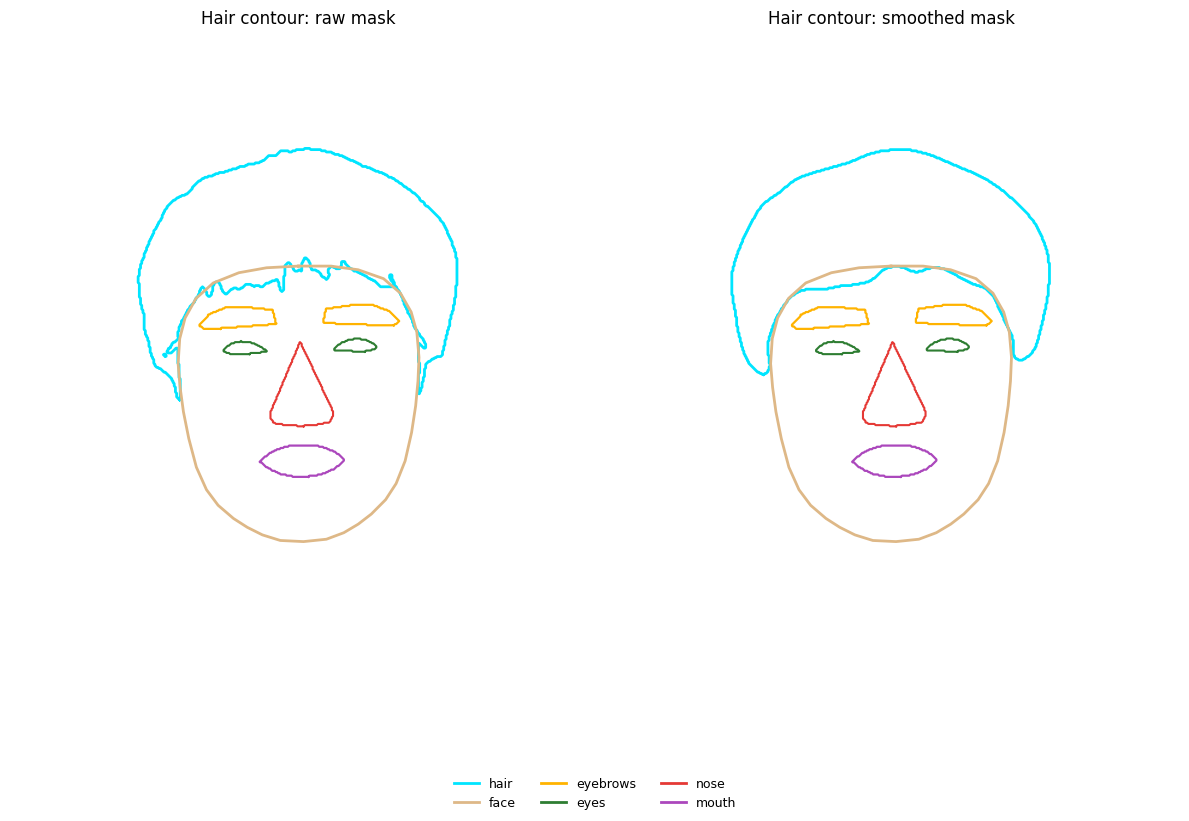

In [7]:
# Same part outlines as above, but hair contour is smoothed (blur + morphology on the hair mask)
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from collections import defaultdict
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.ndimage import gaussian_filter
from scipy.spatial import ConvexHull
from skimage.draw import polygon
from skimage.io import imread
from skimage.measure import find_contours
from skimage.morphology import binary_closing, binary_opening, disk

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

face_model_path = Path("face_landmarker.task")
if not face_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
        face_model_path,
    )
segmenter_model_path = Path("selfie_multiclass_256x256.tflite")
if not segmenter_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite",
        segmenter_model_path,
    )

rgb = imread(face_path)[:, :, :3]
h, w, _ = rgb.shape
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)


def idx_from_connections(connections):
    ids = set()
    for c in connections:
        ids.add(c.start)
        ids.add(c.end)
    return sorted(ids)


def convex_region_mask(points_xy, shape_hw):
    m = np.zeros(shape_hw, dtype=bool)
    pts = np.asarray(points_xy)
    if pts.shape[0] < 3:
        return m
    pts = np.unique(pts, axis=0)
    if pts.shape[0] < 3:
        return m
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    rr, cc = polygon(hull_pts[:, 1], hull_pts[:, 0], shape=shape_hw)
    m[rr, cc] = True
    return m


def plot_mask_outlines(ax, mask, color, linewidth=1.8):
    for contour in find_contours(mask.astype(float), level=0.5):
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=linewidth)


def face_oval_cycle_ordered():
    conns = list(vision.FaceLandmarksConnections.FACE_LANDMARKS_FACE_OVAL)
    adj = defaultdict(set)
    for c in conns:
        adj[c.start].add(c.end)
        adj[c.end].add(c.start)
    start = min(adj.keys())
    order = [start]
    prev, cur = None, start
    for _ in range(len(adj)):
        nbrs = [n for n in adj[cur] if n != prev]
        if not nbrs:
            break
        nxt = nbrs[0]
        order.append(nxt)
        prev, cur = cur, nxt
    return order[:-1]


def smooth_hair_mask(mask, gauss_sigma=7.0, close_radius=12, open_radius=4):
    """Soften jagged segmentation: Gaussian blur on the binary mask, re-threshold, then close/open.
    Increase gauss_sigma / close_radius for a smoother (simpler) outline."""
    m = gaussian_filter(mask.astype(float), sigma=gauss_sigma)
    m = m >= 0.5
    m = binary_closing(m, footprint=disk(close_radius))
    m = binary_opening(m, footprint=disk(open_radius))
    return m


def draw_parts(ax, hair_m, title):
    plot_mask_outlines(ax, hair_m, "#00e5ff", linewidth=2.0)
    ax.plot(oval_xy[:, 0], oval_xy[:, 1], color="#deb887", linewidth=2.0)
    plot_mask_outlines(ax, left_brow_mask, "#ffb300", 1.6)
    plot_mask_outlines(ax, right_brow_mask, "#ffb300", 1.6)
    plot_mask_outlines(ax, left_eye_mask, "#2e7d32", 1.5)
    plot_mask_outlines(ax, right_eye_mask, "#2e7d32", 1.5)
    plot_mask_outlines(ax, nose_mask, "#e53935", 1.5)
    plot_mask_outlines(ax, mouth_mask, "#ab47bc", 1.6)
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)


# --- inference (same as previous cell) ---
face_options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(face_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
)
face_landmarker = vision.FaceLandmarker.create_from_options(face_options)
face_result = face_landmarker.detect(mp_image)
face_landmarker.close()
if not face_result.face_landmarks:
    raise ValueError("No face landmarks detected in face.jpg")

landmarks = face_result.face_landmarks[0]
xy = np.array([(lm.x * w, lm.y * h) for lm in landmarks])

seg_options = vision.ImageSegmenterOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(segmenter_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    output_category_mask=True,
)
segmenter = vision.ImageSegmenter.create_from_options(seg_options)
seg_result = segmenter.segment(mp_image)
segmenter.close()
category_mask = np.squeeze(seg_result.category_mask.numpy_view())
hair_mask = category_mask == 1

left_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYE)
right_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYE)
left_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYEBROW)
right_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYEBROW)
nose_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_NOSE)
mouth_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LIPS)

left_eye_mask = convex_region_mask(xy[left_eye_idx], (h, w))
right_eye_mask = convex_region_mask(xy[right_eye_idx], (h, w))
left_brow_mask = convex_region_mask(xy[left_brow_idx], (h, w))
right_brow_mask = convex_region_mask(xy[right_brow_idx], (h, w))
nose_mask = convex_region_mask(xy[nose_idx], (h, w))
mouth_mask = convex_region_mask(xy[mouth_idx], (h, w))

oval_lm = face_oval_cycle_ordered()
oval_closed = np.array(oval_lm + [oval_lm[0]], dtype=int)
oval_xy = xy[oval_closed]

hair_smooth = smooth_hair_mask(hair_mask, gauss_sigma=7.0, close_radius=12, open_radius=4)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
draw_parts(ax0, hair_mask, "Hair contour: raw mask")
draw_parts(ax1, hair_smooth, "Hair contour: smoothed mask")

legend_elems = [
    plt.Line2D([0], [0], color="#00e5ff", lw=2, label="hair"),
    plt.Line2D([0], [0], color="#deb887", lw=2, label="face"),
    plt.Line2D([0], [0], color="#ffb300", lw=2, label="eyebrows"),
    plt.Line2D([0], [0], color="#2e7d32", lw=2, label="eyes"),
    plt.Line2D([0], [0], color="#e53935", lw=2, label="nose"),
    plt.Line2D([0], [0], color="#ab47bc", lw=2, label="mouth"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, frameon=False, fontsize=9)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()


### Cell 8 — Face oval + ears + smoothed hair

**Purpose:** **Face** boundary = same **MediaPipe oval** polyline as cell 6. **Ears** = **face-skin** pixels **outside** the filled oval; split left/right at the nose; **keep largest connected component** per side; light **smoothing** on ear masks. Hair uses the same smoothing as cell 7.


W0000 00:00:1778497668.934236 13076373 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778497668.939974 13076373 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497668.941551 13076376 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778497668.952789 13076377 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1778497669.054900 13076384 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1778497669.069165 13076389 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/914836534.py:114: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, footprint=disk(close_radius))
/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/914836534.py:115: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  m = binary_opening(m, footprint=disk(open_radius))
/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/914836534.py:170: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  ears_all = binary_opening(binary_closing(ears_all, footprint=disk(2)), footprint=disk(1))
/var/folders/1l/53g0slzx4hsgs_p65dtmhrsr0000gn/T/ipykernel_98339/914836534.py:170: FutureWarning: `binary_opening` is de

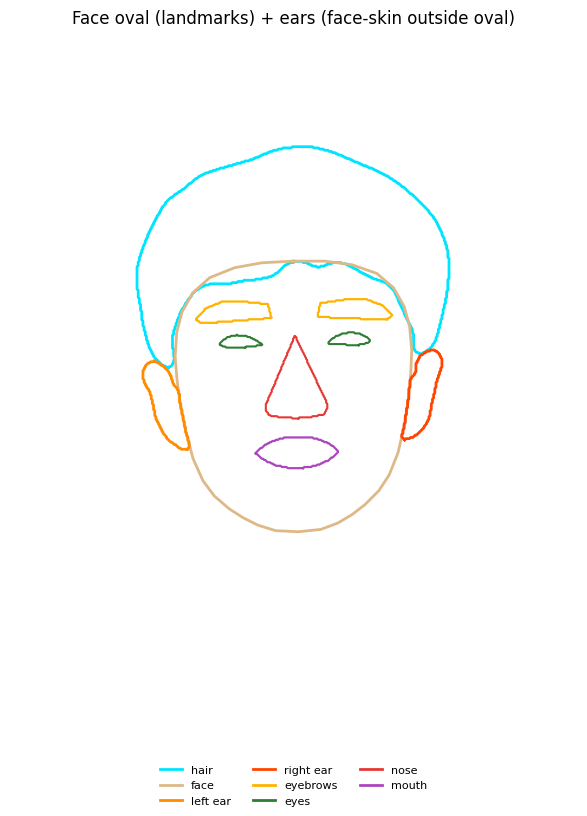

In [8]:
# Face boundary = MediaPipe face oval polyline (same as the "Part outlines" cell).
# Ears = face-skin segmentation outside the filled oval polygon. Hair = smoothed mask.
from pathlib import Path
import urllib.request

import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from collections import defaultdict
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from scipy.ndimage import gaussian_filter
from scipy.spatial import ConvexHull
from skimage.draw import polygon
from skimage.io import imread
from skimage.measure import find_contours, label, regionprops
from skimage.morphology import binary_closing, binary_opening, disk

face_path = Path("face.jpg")
if not face_path.exists():
    raise FileNotFoundError("face.jpg not found in the project root")

face_model_path = Path("face_landmarker.task")
if not face_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task",
        face_model_path,
    )
segmenter_model_path = Path("selfie_multiclass_256x256.tflite")
if not segmenter_model_path.exists():
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_multiclass_256x256/float32/latest/selfie_multiclass_256x256.tflite",
        segmenter_model_path,
    )

rgb = imread(face_path)[:, :, :3]
h, w, _ = rgb.shape
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)


def idx_from_connections(connections):
    ids = set()
    for c in connections:
        ids.add(c.start)
        ids.add(c.end)
    return sorted(ids)


def convex_region_mask(points_xy, shape_hw):
    m = np.zeros(shape_hw, dtype=bool)
    pts = np.asarray(points_xy)
    if pts.shape[0] < 3:
        return m
    pts = np.unique(pts, axis=0)
    if pts.shape[0] < 3:
        return m
    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    rr, cc = polygon(hull_pts[:, 1], hull_pts[:, 0], shape=shape_hw)
    m[rr, cc] = True
    return m


def plot_mask_outlines(ax, mask, color, linewidth=1.8):
    for contour in find_contours(mask.astype(float), level=0.5):
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=linewidth)


def keep_largest_region(mask):
    if not mask.any():
        return mask
    lab = label(mask, connectivity=2)
    props = regionprops(lab)
    if not props:
        return mask
    best = max(props, key=lambda r: r.area)
    return lab == best.label


def smooth_ear_mask(mask, sigma=2.2, close_radius=3, open_radius=1):
    if not mask.any():
        return mask
    m = gaussian_filter(mask.astype(float), sigma=sigma)
    m = m >= 0.5
    if close_radius > 0:
        m = binary_closing(m, footprint=disk(close_radius))
    if open_radius > 0:
        m = binary_opening(m, footprint=disk(open_radius))
    return m


def face_oval_cycle_ordered():
    conns = list(vision.FaceLandmarksConnections.FACE_LANDMARKS_FACE_OVAL)
    adj = defaultdict(set)
    for c in conns:
        adj[c.start].add(c.end)
        adj[c.end].add(c.start)
    start = min(adj.keys())
    order = [start]
    prev, cur = None, start
    for _ in range(len(adj)):
        nbrs = [n for n in adj[cur] if n != prev]
        if not nbrs:
            break
        nxt = nbrs[0]
        order.append(nxt)
        prev, cur = cur, nxt
    return order[:-1]


def smooth_hair_mask(mask, gauss_sigma=7.0, close_radius=12, open_radius=4):
    m = gaussian_filter(mask.astype(float), sigma=gauss_sigma)
    m = m >= 0.5
    m = binary_closing(m, footprint=disk(close_radius))
    m = binary_opening(m, footprint=disk(open_radius))
    return m


# --- inference ---
face_options = vision.FaceLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(face_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
)
face_landmarker = vision.FaceLandmarker.create_from_options(face_options)
face_result = face_landmarker.detect(mp_image)
face_landmarker.close()
if not face_result.face_landmarks:
    raise ValueError("No face landmarks detected in face.jpg")

landmarks = face_result.face_landmarks[0]
xy = np.array([(lm.x * w, lm.y * h) for lm in landmarks])

seg_options = vision.ImageSegmenterOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(segmenter_model_path)),
    running_mode=vision.RunningMode.IMAGE,
    output_category_mask=True,
)
segmenter = vision.ImageSegmenter.create_from_options(seg_options)
seg_result = segmenter.segment(mp_image)
segmenter.close()
category_mask = np.squeeze(seg_result.category_mask.numpy_view())
hair_mask = category_mask == 1
face_skin_mask = category_mask == 3
hair_smooth = smooth_hair_mask(hair_mask)

left_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYE)
right_eye_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYE)
left_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LEFT_EYEBROW)
right_brow_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_EYEBROW)
nose_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_NOSE)
mouth_idx = idx_from_connections(vision.FaceLandmarksConnections.FACE_LANDMARKS_LIPS)

left_eye_mask = convex_region_mask(xy[left_eye_idx], (h, w))
right_eye_mask = convex_region_mask(xy[right_eye_idx], (h, w))
left_brow_mask = convex_region_mask(xy[left_brow_idx], (h, w))
right_brow_mask = convex_region_mask(xy[right_brow_idx], (h, w))
nose_mask = convex_region_mask(xy[nose_idx], (h, w))
mouth_mask = convex_region_mask(xy[mouth_idx], (h, w))

oval_lm = face_oval_cycle_ordered()
oval_closed = np.array(oval_lm + [oval_lm[0]], dtype=int)
oval_xy = xy[oval_closed]

rr, cc = polygon(oval_xy[:, 1], oval_xy[:, 0], shape=(h, w))
inside_oval = np.zeros((h, w), dtype=bool)
inside_oval[rr, cc] = True

ears_all = face_skin_mask & ~inside_oval
ears_all = binary_opening(binary_closing(ears_all, footprint=disk(2)), footprint=disk(1))

nose_x = float(xy[1, 0])
_, xx = np.mgrid[0:h, 0:w]
ear_L = ears_all & (xx < nose_x)
ear_R = ears_all & (xx >= nose_x)
ear_L = keep_largest_region(ear_L)
ear_R = keep_largest_region(ear_R)
ear_L = keep_largest_region(smooth_ear_mask(ear_L))
ear_R = keep_largest_region(smooth_ear_mask(ear_R))

fig, ax = plt.subplots(figsize=(6, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plot_mask_outlines(ax, hair_smooth, "#00e5ff", linewidth=2.0)
ax.plot(oval_xy[:, 0], oval_xy[:, 1], color="#deb887", linewidth=2.0)
plot_mask_outlines(ax, ear_L, "#ff8c00", 2.0)
plot_mask_outlines(ax, ear_R, "#ff4500", 2.0)
plot_mask_outlines(ax, left_brow_mask, "#ffb300", 1.6)
plot_mask_outlines(ax, right_brow_mask, "#ffb300", 1.6)
plot_mask_outlines(ax, left_eye_mask, "#2e7d32", 1.5)
plot_mask_outlines(ax, right_eye_mask, "#2e7d32", 1.5)
plot_mask_outlines(ax, nose_mask, "#e53935", 1.5)
plot_mask_outlines(ax, mouth_mask, "#ab47bc", 1.6)

ax.set_xlim(0, w)
ax.set_ylim(h, 0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Face oval (landmarks) + ears (face-skin outside oval)")

legend_elems = [
    plt.Line2D([0], [0], color="#00e5ff", lw=2, label="hair"),
    plt.Line2D([0], [0], color="#deb887", lw=2, label="face"),
    plt.Line2D([0], [0], color="#ff8c00", lw=2, label="left ear"),
    plt.Line2D([0], [0], color="#ff4500", lw=2, label="right ear"),
    plt.Line2D([0], [0], color="#ffb300", lw=2, label="eyebrows"),
    plt.Line2D([0], [0], color="#2e7d32", lw=2, label="eyes"),
    plt.Line2D([0], [0], color="#e53935", lw=2, label="nose"),
    plt.Line2D([0], [0], color="#ab47bc", lw=2, label="mouth"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, frameon=False, fontsize=8)
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()
